In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=';')

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [5]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


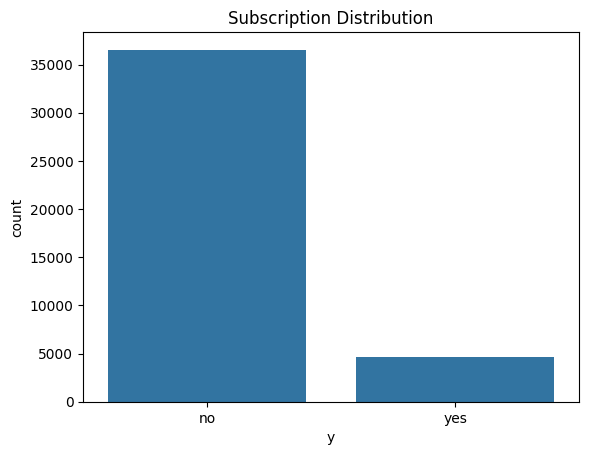

In [6]:
sns.countplot(x='y', data=df)
plt.title("Subscription Distribution")
plt.show()

In [8]:
df = df.drop("duration", axis=1)

In [9]:
X = df.drop("y", axis=1)
y = df["y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (41188, 19)
Target shape: (41188,)


In [10]:
y = y.map({"yes": 1, "no": 0})

In [11]:
X = pd.get_dummies(X, drop_first=True)

print("New shape after encoding:", X.shape)

New shape after encoding: (41188, 52)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for imbalance
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (32950, 52)
Testing size: (8238, 52)


In [13]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5   # limit depth to avoid overfitting
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [14]:
y_pred_dt = dt_model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_dt))

Accuracy: 0.9021607186210245

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.68      0.25      0.36       928

    accuracy                           0.90      8238
   macro avg       0.80      0.62      0.66      8238
weighted avg       0.89      0.90      0.88      8238

ROC-AUC Score: 0.6165352728902306


In [16]:
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

[[7202  108]
 [ 698  230]]


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=12,            # limit depth to avoid overfitting
    random_state=42,
    class_weight='balanced', # important for imbalance
    n_jobs=-1                # use all CPU cores
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [18]:
y_pred_rf = rf_model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.8712066035445496

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.90      0.93      7310
           1       0.45      0.62      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238

ROC-AUC Score: 0.7618496155479032


In [20]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [21]:
from sklearn.metrics import classification_report, accuracy_score

thresholds = [0.5, 0.4, 0.3]

for threshold in thresholds:
    print("\n==============================")
    print("Threshold:", threshold)

    y_pred_custom = (y_prob_rf >= threshold).astype(int)

    print("Accuracy:", accuracy_score(y_test, y_pred_custom))
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.5
Accuracy: 0.8712066035445496
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      7310
           1       0.45      0.62      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238


Threshold: 0.4
Accuracy: 0.8192522456907017
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      7310
           1       0.35      0.68      0.46       928

    accuracy                           0.82      8238
   macro avg       0.65      0.76      0.68      8238
weighted avg       0.89      0.82      0.84      8238


Threshold: 0.3
Accuracy: 0.6075503763049284
              precision    recall  f1-score   support

           0       0.96      0.58      0.72      7310
           1       0.20      0.83      0.32       928

    accuracy                           0.61    

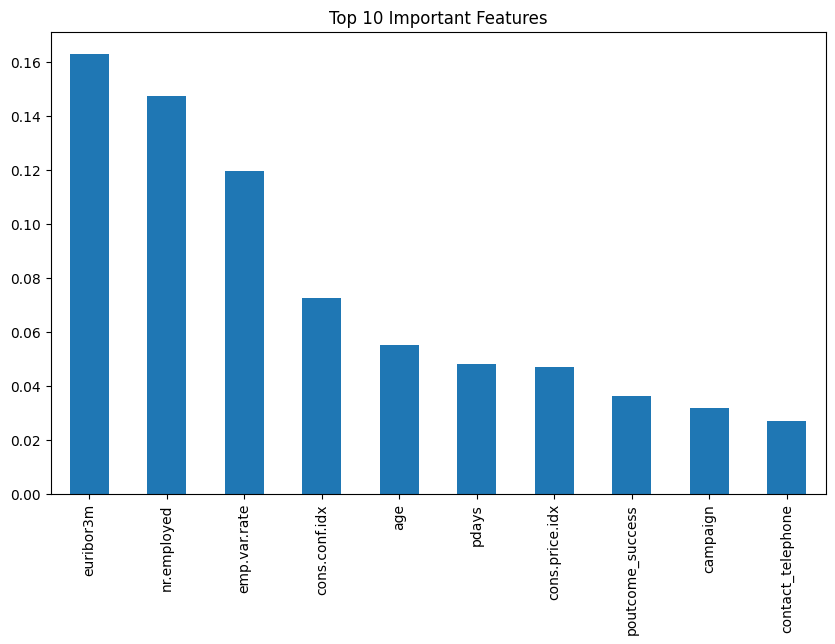

,0
euribor3m,0.163203
nr.employed,0.147534
emp.var.rate,0.119670
cons.conf.idx,0.072684
age,0.055217
pdays,0.048096
cons.price.idx,0.047065
poutcome_success,0.036087
campaign,0.031628
contact_telephone,0.027110


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

feature_importances.head(10)